# `semialg` demo: semialgebraic computation, CAD/QE, RUR, regions, and applications

This notebook is a guided tour of `semialg`. It is written as both a runnable demo and a compact introduction to the mathematics behind exact real-algebraic computation.

My main goals for this notebook are to show you how to:

1. build semialgebraic formulas in SymPy;
2. decide satisfiability and find witnesses;
3. use CAD and quantifier elimination;
4. solve finite polynomial systems with a rational univariate representation (RUR);
5. combine region algebra, plotting, optimization, integration, and moments;
6. understand limitations and performance tradeoffs.

The examples are intentionally small. CAD and real quantifier elimination are powerful but can become expensive quickly, so the best demonstrations are simple enough to inspect by hand while still showing the core ideas.


## 1. Mathematical background

An **algebraic set** is the set of common zeros of polynomial equations. For example,

$$
V(x^2+y^2-1)=\{(x,y)\in\mathbb R^2:x^2+y^2=1\}
$$

is the unit circle.

A **semialgebraic set** allows polynomial equations and inequalities combined with Boolean operations:

$$
S=\{(x,y): x^2+y^2\le 1 \;\wedge\; y\ge x^2-1/2\}.
$$

The first-order theory of real closed fields says that every formula built from polynomial equalities, inequalities, Boolean connectives, and quantifiers over the reals can be transformed into an equivalent quantifier-free formula. This is the theoretical basis for exact decision procedures over semialgebraic sets.

Important operations include:

- **satisfiability**: is there a real point satisfying the formula?
- **quantifier elimination**: remove variables such as $\exists y$ or $\forall x$;
- **projection**: describe the shadow of a set on fewer coordinates;
- **decomposition**: split space into cells on which polynomial signs are invariant;
- **optimization and range finding**: determine exact global bounds;
- **integration and moments**: compute geometric quantities over exact regions.


## 2. Algorithmic map and decision guide

`semialg` exposes several related workflows. The table below is a practical guide.

| Goal | Typical function |
|---|---|
| Decide if a formula has a real solution | `is_satisfiable`, `find_instance` |
| Reduce a quantified formula | `reduce_text`, `reduce_formula`, `qe_by_complete_cad` |
| Decompose a formula into CAD cells | `cad` |
| Solve finitely many polynomial equations exactly | `solve_zero_dimensional_system` |
| Use the RUR backend opportunistically | `solve_zero_dimensional_system(..., backend="auto")` |
| Find a function range | `function_range` |
| Optimize over a semialgebraic region | `semialgebraic_minimize`, `semialgebraic_maximize` |
| Compute area, volume, integrals, centroids, moments | `semialgebraic_measure`, `integrate_over_region`, `region_centroid`, `region_moment` |
| Build region unions/intersections/differences | `region_union`, `region_intersection`, `region_difference` |
| Visualize a two-dimensional formula | `plot_solution` |

A useful mental model is:

- use **RUR** when the equality system has finitely many solutions;
- use **CAD/QE** when quantifiers, inequalities, projections, and positive-dimensional regions matter;
- use **plotting/sampling** for visualization, not proof;
- use **specialized shortcuts** when the problem is one-dimensional, linear, quadratic, radial, or otherwise structured.


## 3. Setup

Run this notebook from the "notebooks" folder under the repository root, or install the project first with:

```bash
pip install -e .
```

The helper `show_call` below keeps later cells readable: it prints the value if the backend supports the example and prints the exception class if a feature is intentionally incomplete.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

repo_root = Path.cwd().parent
if (repo_root / "src" / "semialg").exists():
    sys.path.insert(0, str(repo_root / "src"))

import sympy as sp

from semialg import (
    cad,
    cad_text,
    classify_real_roots,
    equivalent,
    find_instance,
    function_domain,
    function_range,
    implies,
    integrate_over_region,
    is_real_valued,
    is_satisfiable,
    normalize_domain_sensitive_constraints,
    plot_region_geometry,
    plot_solution,
    prove_nonnegative,
    reduce_text,
    region_boundary,
    region_centroid,
    region_closure,
    region_complement,
    region_components,
    region_covariance,
    region_difference,
    region_dimension,
    region_interior,
    region_intersection,
    region_moment,
    region_union,
    sample_point,
    sample_points,
    semialgebraic_maximize,
    semialgebraic_measure,
    semialgebraic_minimize,
    simplify_boole,
    simplify_under_assumptions,
    solve_semialgebraic,
    solve_zero_dimensional_system,
)

x, y, z, a, b, c, d, k, r, t = sp.symbols("x y z a b c d k r t", real=True)

def show_call(label, thunk):
    print(f"\n--- {label} ---")
    try:
        value = thunk()
        print(value)
        return value
    except Exception as exc:
        print(f"{type(exc).__name__}: {exc}")
        return None


## 4. Building formulas in SymPy

In SymPy, use relational operators such as `<=`, `>=`, `==`, and Boolean operators such as `&`, `|`, and `~`.

Use parentheses around comparisons before combining them with `&` or `|`.


In [2]:
disk = x**2 + y**2 <= 1
upper_half = y >= 0
right_half = x >= 0
first_quadrant_disk = disk & upper_half & right_half
first_quadrant_disk


(x >= 0) & (y >= 0) & (x**2 + y**2 <= 1)

In [3]:
# Text input is also available for quantified formulas.
show_call(
    "textual quantified formula",
    lambda: reduce_text("forall x. (-1 <= x and x <= 1) implies x^2 <= b", variable_order=[b, x]),
)



--- textual quantified formula ---
b >= 1


b >= 1

## 5. Basic decision procedures

Decision procedures answer yes/no questions or return witnesses. These functions are often the easiest entry point.


In [4]:
show_call("satisfiable first-quadrant disk", lambda: is_satisfiable(first_quadrant_disk, [x, y]))
show_call("find one witness", lambda: find_instance(first_quadrant_disk, [x, y]))
show_call("sample several witnesses", lambda: sample_points(first_quadrant_disk, [x, y], count=5))



--- satisfiable first-quadrant disk ---
True

--- find one witness ---
InstanceResult(instances=({x: 0, y: 0},), approximate=({x: 0.0, y: 0.0},), variables=(x, y), domain=<SolveDomain.REALS: 'reals'>, status=<SolverStatus.SAT: 'sat'>, method='fast_real_heuristics_instance', exact=True, diagnostics={'fallback_status': 'satisfied', 'fallback_method': 'fast_real_heuristics', 'fallback_attempts': ({'name': 'origin_probe', 'status': 'satisfied', 'details': {}},)}, random_seed=None)

--- sample several witnesses ---
({x: 0, y: 0}, {x: 0, y: 1}, {x: 0, y: 1/2}, {x: 0, y: 1/3}, {x: 0, y: 1/4})


({x: 0, y: 0}, {x: 0, y: 1}, {x: 0, y: 1/2}, {x: 0, y: 1/3}, {x: 0, y: 1/4})

In [5]:
show_call("implication", lambda: implies(x > 1, x**2 > 1, [x]))
show_call("equivalence", lambda: equivalent(x**2 <= 1, (x >= -1) & (x <= 1), [x]))



--- implication ---
True

--- equivalence ---
True


True

## 6. Formula lifecycle workflow

A useful way to learn the package is to pass the same formula through several APIs: decomposition, solving, sampling, measure, optimization, and plotting.


In [6]:
region = (x**2 + y**2 <= 1) & (y >= x**2 - sp.Rational(1, 2))

show_call("CAD decomposition", lambda: cad(region, variables=[x, y]))
show_call("structured solution", lambda: solve_semialgebraic(region, [x, y], count=3))
show_call("one sample point", lambda: sample_point(region, [x, y]))
show_call("area / measure", lambda: semialgebraic_measure(region, [x, y]))
show_call("maximize y", lambda: semialgebraic_maximize(y, region, [x, y]))



--- CAD decomposition ---
TypeError: Invalid comparison of non-real sqrt(2)*3**(1/4)*I/2

--- structured solution ---
SemialgebraicSolution(formula=(y >= x**2 - 1/2) & (x**2 + y**2 <= 1), variables=(x, y), samples=({x: 0, y: 1/4},), satisfiable=True, method='vertical_bounds_2d', diagnostics={'input_formula': '(y >= x**2 - 1/2) & (x**2 + y**2 <= 1)', 'solver_stage': 'semialgebraic_solution', 'capabilities': {'component_decomposition': 'one_dimensional', 'parameter_conditions': True, 'vertical_cells': 'two_dimensional', 'structural_sampling': True, 'set_operations': True, 'plotting_data': True}, 'full_cylindrical_solution': True, 'selected_output': None, 'selected_sample_mode': 'auto', 'requested_sample_count': 3, 'structural_sample_count': 1, 'simplified_constraint_count': 2, 'has_parameter_conditions': False, 'has_parameter_decomposition': False, 'used_rur': False, 'backend': 'auto', 'normalization_steps': (), 'removed_redundant_constraints': (), 'unsupported_features': (), 'requested

OptimizationResult(objective=y, variables=(x, y), value=1, points=({x: 0, y: 1},), attained=True, kind='max', method='critical_point_enumeration', diagnostics={'candidate_count': 4, 'constraints': '(y >= x**2 - 1/2) & (x**2 + y**2 <= 1)'})

## 7. CAD: decomposition, not only solving

A **cylindrical algebraic decomposition** partitions real space into cells arranged cylindrically. In two variables, the algorithm first decomposes the $x$-axis, then lifts each $x$-cell into cells in the $y$ direction. Polynomial signs are invariant on each cell.

CAD is useful because sign-invariant cells make logical formulas decidable: evaluate the formula at one sample point per cell.


In [7]:
parabolic_strip = (y >= x**2) & (y <= 1)
strip_cad = show_call("CAD for parabolic strip", lambda: cad(parabolic_strip, variables=[x, y]))

if strip_cad is not None:
    print("formula:", getattr(strip_cad, "formula", None))
    print("number of samples:", len(getattr(strip_cad, "samples", ()) or ()))
    print("number of cells:", len(getattr(strip_cad, "cells", ()) or ()))



--- CAD for parabolic strip ---
CADResult(formula=(Eq(x, 0) & Eq(y, 1)) | (Eq(x, 0) & (y > 0) & (y < 1)) | (Eq(y, 1) & (x > -1) & (x < 0)) | (Eq(y, 1) & (x > 0) & (x < 1)) | (Eq(x, -1) & Eq(x**2 - y, 0)) | (Eq(x, 0) & Eq(x**2 - y, 0)) | (Eq(x, 1) & Eq(x**2 - y, 0)) | ((x > -1) & (x < 0) & Eq(x**2 - y, 0)) | ((x > 0) & (x < 1) & Eq(x**2 - y, 0)) | ((x > -1) & (x < 0) & (y < 1) & (x**2 - y < 0)) | ((x > 0) & (x < 1) & (y < 1) & (x**2 - y < 0)), variables=(x, y), cad=CompleteCAD(tower=ProjectionTower(variables=(x, y), levels=(ProjectionLevel(level=1, variable=x, polynomials=(Poly(x, x, domain='ZZ'), Poly(x**2 - 1, x, domain='ZZ')), entries=(ProjectionPolynomial(poly=Poly(x, x, domain='ZZ'), level=1, source='coefficient', parents=('x**2 - y',), operation_variable=y, expression=x**2), ProjectionPolynomial(poly=Poly(x**2 - 1, x, domain='ZZ'), level=1, source='resultant', parents=('x**2 - y', 'y - 1'), operation_variable=y, expression=1 - x**2))), ProjectionLevel(level=2, variable=y, polynom

## 8. Quantifier elimination and projections

Quantifier elimination turns formulas such as

$$
\exists y\; \Phi(x,y)
$$

into an equivalent quantifier-free condition in the remaining variables. Geometrically, existential quantification is projection: it describes the shadow of a region.


In [8]:
show_call(
    "maximum of x^2 on [-1, 1] encoded by forall/implies",
    lambda: reduce_text("forall x. (-1 <= x and x <= 1) implies x^2 <= b", variable_order=[b, x]),
)

show_call(
    "quadratic nonnegativity parameter range",
    lambda: reduce_text("forall x. x^2 + k*x + 1 >= 0", variable_order=[k, x]),
)

show_call(
    "real root condition for x^2 + a*x + 1",
    lambda: reduce_text("exists x. x^2 + a*x + 1 = 0", variable_order=[a, x]),
)



--- maximum of x^2 on [-1, 1] encoded by forall/implies ---
b >= 1

--- quadratic nonnegativity parameter range ---
Eq(k, -2) | Eq(k, 0) | Eq(k, 2) | ((k > -2) & (k < 0)) | ((k > 0) & (k < 2))

--- real root condition for x^2 + a*x + 1 ---
Eq(a, -2) | Eq(a, 2) | (a > 2) | (a < -2)


Eq(a, -2) | Eq(a, 2) | (a > 2) | (a < -2)

In [9]:
show_call(
    "overlap of two radius-r intervals centered distance d apart",
    lambda: reduce_text("exists x. x^2 <= r^2 and (x - d)^2 <= r^2", variable_order=[d, r, x]),
)



--- overlap of two radius-r intervals centered distance d apart ---
TypeError: expecting bool or Boolean, not `r**2`.


## 9. Text interface examples

The text interface is useful when you want to write formulas close to ordinary mathematical notation.

Currently supported examples include `exists`, `forall`, `and`, `or`, `not`, and top-level `implies`.


In [10]:
text_examples = [
    ("unit interval square bound", "forall x. (-1 <= x and x <= 1) implies x^2 <= b", [b, x]),
    ("quadratic has a real root", "exists x. x^2 + a*x + 1 = 0", [a, x]),
    ("quadratic is globally nonnegative", "forall x. x^2 + k*x + 1 >= 0", [k, x]),
    ("disk supports a large linear functional", "exists x. exists y. x^2 + y^2 <= 1 and x + y >= c", [c, x, y]),
]

for label, text, order in text_examples:
    show_call(label, lambda text=text, order=order: reduce_text(text, variable_order=order))



--- unit interval square bound ---
b >= 1

--- quadratic has a real root ---
Eq(a, -2) | Eq(a, 2) | (a > 2) | (a < -2)

--- quadratic is globally nonnegative ---
Eq(k, -2) | Eq(k, 0) | Eq(k, 2) | ((k > -2) & (k < 0)) | ((k > 0) & (k < 2))

--- disk supports a large linear functional ---
TypeError: expecting bool or Boolean, not `x + y`.


## 10. RUR: exact zero-dimensional solving

A **rational univariate representation** reduces a finite multivariate polynomial system to one univariate algebraic parameter.

For a zero-dimensional system, choose a separating linear form

$$
t = \ell(x_1,\ldots,x_n),
$$

then represent each coordinate by a rational function of $t$:

$$
q(t)=0,\qquad x_i = \frac{q_i(t)}{q_0(t)}.
$$

This is especially useful for exact isolated solutions, critical points, boundary intersections, and finite feasible sets. It is not a replacement for CAD on positive-dimensional regions, but it is an efficient backend when the equality system is finite.


In [11]:
show_call(
    "RUR for circle-line intersection",
    lambda: solve_zero_dimensional_system([x**2 + y**2 - 1, x - y], vars=[x, y], backend="rur"),
)

show_call(
    "RUR with inequality filtering",
    lambda: solve_zero_dimensional_system(
        [x**2 + y**2 - 1, x**2 - y],
        inequalities=[x >= 0, y >= 0],
        vars=[x, y],
        backend="rur",
    ),
)

show_call(
    "multiplicity example: quotient dimension differs from distinct geometric points",
    lambda: solve_zero_dimensional_system([x**2, y - 1], vars=[x, y], backend="rur"),
)



--- RUR for circle-line intersection ---
ZeroDimensionalSolveResult(variables=(x, y), points=((-sqrt(2)/2, -sqrt(2)/2), (sqrt(2)/2, sqrt(2)/2)), backend='rational_univariate', status='satisfied', representation=RationalUnivariateRepresentation(variables=(x, y), parameter=_rur_t, defining_polynomial=Poly(_rur_t**2 - 2, _rur_t, domain='QQ'), coordinate_denominator=Poly(2*_rur_t, _rur_t, domain='QQ'), coordinate_numerators=(Poly(2, _rur_t, domain='QQ'), Poly(2, _rur_t, domain='QQ')), separating_linear_form=x + y, standard_exponents=((0, 0), (0, 1)), quotient_dimension=2, geometric_solution_count=2), notes=('quotient_dimension=2', 'geometric_solution_count=2', 'separating_linear_form=x + y'))

--- RUR with inequality filtering ---
ZeroDimensionalSolveResult(variables=(x, y), points=((-3/4 + CRootOf(x**4 + 2*x**3 - 6*x - 1, 1)/4 + CRootOf(x**4 + 2*x**3 - 6*x - 1, 1)**2/4 + CRootOf(x**4 + 2*x**3 - 6*x - 1, 1)**3/4, -CRootOf(x**4 + 2*x**3 - 6*x - 1, 1)**3/4 - CRootOf(x**4 + 2*x**3 - 6*x - 1,

ZeroDimensionalSolveResult(variables=(x, y), points=((0, 1),), backend='rational_univariate', status='satisfied', representation=RationalUnivariateRepresentation(variables=(x, y), parameter=_rur_t, defining_polynomial=Poly(_rur_t - 1, _rur_t, domain='QQ'), coordinate_denominator=Poly(2, _rur_t, domain='QQ'), coordinate_numerators=(Poly(0, _rur_t, domain='QQ'), Poly(2, _rur_t, domain='QQ')), separating_linear_form=x + y, standard_exponents=((0, 0), (1, 0)), quotient_dimension=2, geometric_solution_count=1), notes=('quotient_dimension=2', 'geometric_solution_count=1', 'separating_linear_form=x + y'))

### How the RUR backend fits into higher-level algorithms

The intended dispatch pattern is:

```python
if is_zero_dimensional(equations):
    return solve_by_rur(equations, inequalities, vars)
else:
    return solve_by_cad_or_regular_chains(...)
```

In practical terms:

- RUR is preferred for finite equality systems;
- CAD/QE remains the general method for inequalities, quantified formulas, projections, and positive-dimensional sets;
- inequality filtering after RUR is a univariate sign-determination problem on algebraic roots.


## 11. Region algebra: union, intersection, difference, complement

Semialgebraic sets are closed under Boolean operations. Region algebra lets you build new formulas from old ones while keeping them symbolic.


In [12]:
disk1 = x**2 + y**2 <= 1
disk2 = (x - sp.Rational(1, 2))**2 + y**2 <= 1

lens = region_intersection(disk1, disk2)
crescent = region_difference(disk1, disk2)
two_disk_union = region_union(disk1, disk2)

show_call("lens formula", lambda: simplify_boole(lens))
show_call("crescent formula", lambda: simplify_boole(crescent))
show_call("union formula", lambda: simplify_boole(two_disk_union))



--- lens formula ---
(x**2 + y**2 - 1 <= 0) & (4*x**2 - 4*x + 4*y**2 - 3 <= 0)

--- crescent formula ---
(x**2 + y**2 - 1 <= 0) & (4*x**2 - 4*x + 4*y**2 - 3 > 0)

--- union formula ---
(x**2 + y**2 - 1 <= 0) | (4*x**2 - 4*x + 4*y**2 - 3 <= 0)


(x**2 + y**2 - 1 <= 0) | (4*x**2 - 4*x + 4*y**2 - 3 <= 0)

## 12. Function ranges

Function ranges can be encoded by quantifier elimination:

$$
t \in f(S) \iff \exists x\in S\; t=f(x).
$$

This is one of the most useful practical interpretations of QE.


In [13]:
show_call("range of x^2 on [-1, 2]", lambda: function_range(x**2, (x >= -1) & (x <= 2), [x]))
show_call("range of 1/x over x > 0", lambda: function_range(1/x, x > 0, [x]))
show_call("range of x + y over unit disk", lambda: function_range(x + y, x**2 + y**2 <= 1, [x, y], method="auto"))



--- range of x^2 on [-1, 2] ---
(t >= 0) & (t <= 4)

--- range of 1/x over x > 0 ---
t > 0

--- range of x + y over unit disk ---
Abs(t) <= sqrt(2)


Abs(t) <= sqrt(2)

## 13. Global optimization

Exact semialgebraic optimization searches globally, not only locally. Typical workflows reduce extrema to boundary candidates, critical points, and feasibility checks.


In [14]:
unit_disk = x**2 + y**2 <= 1
linear_objective = x + 2*y

show_call("maximize x + 2y over the disk", lambda: semialgebraic_maximize(linear_objective, unit_disk, [x, y]))
show_call("minimize x + 2y over the disk", lambda: semialgebraic_minimize(linear_objective, unit_disk, [x, y]))



--- maximize x + 2y over the disk ---
OptimizationResult(objective=x + 2*y, variables=(x, y), value=sqrt(5), points=({x: sqrt(5)/5, y: 2*sqrt(5)/5},), attained=True, kind='max', method='critical_point_enumeration', diagnostics={'candidate_count': 2, 'constraints': 'x**2 + y**2 <= 1'})

--- minimize x + 2y over the disk ---
OptimizationResult(objective=x + 2*y, variables=(x, y), value=-sqrt(5), points=({x: -sqrt(5)/5, y: -2*sqrt(5)/5},), attained=True, kind='min', method='critical_point_enumeration', diagnostics={'candidate_count': 2, 'constraints': 'x**2 + y**2 <= 1'})


OptimizationResult(objective=x + 2*y, variables=(x, y), value=-sqrt(5), points=({x: -sqrt(5)/5, y: -2*sqrt(5)/5},), attained=True, kind='min', method='critical_point_enumeration', diagnostics={'candidate_count': 2, 'constraints': 'x**2 + y**2 <= 1'})

In [15]:
nonconvex_region = ((x - 1)**2 + y**2 <= 1) | ((x + 1)**2 + y**2 <= 1)
nonconvex_objective = y - x**2
show_call("maximize y - x^2 over two disks", lambda: semialgebraic_maximize(nonconvex_objective, nonconvex_region, [x, y]))



--- maximize y - x^2 over two disks ---
NotImplementedError: optimization candidate enumeration currently supports conjunctions


## 14. Measure, integration, centroids, and moments

Semialgebraic formulas can describe regions for symbolic integration. These routines are useful for computational geometry, probability over regions, mechanics, and statistics.


In [16]:
triangle = (x >= 0) & (x <= 1) & (y >= x) & (y <= 1)

show_call("triangle area", lambda: semialgebraic_measure(triangle, [x, y]))
show_call("integral of x + y over triangle", lambda: integrate_over_region(x + y, triangle, [x, y]))
show_call("triangle centroid", lambda: region_centroid(triangle, [x, y]))
show_call("moment ∫ x^2 dA", lambda: region_moment(triangle, [x, y], powers=(2, 0)))
show_call("covariance over triangle", lambda: region_covariance(triangle, [x, y]))



--- triangle area ---
1/2

--- integral of x + y over triangle ---
1/2

--- triangle centroid ---
{x: 1/3, y: 2/3}

--- moment ∫ x^2 dA ---
1/12

--- covariance over triangle ---
Matrix([[1/18, 1/36], [1/36, 1/18]])


Matrix([
[1/18, 1/36],
[1/36, 1/18]])

## 15. Boundaries, interiors, closures, and dimensions

Strict and non-strict inequalities matter. For example, the open disk and closed disk have the same closure but different boundary membership.


In [17]:
open_disk = x**2 + y**2 < 1
closed_disk = x**2 + y**2 <= 1

show_call("closure of open disk", lambda: region_closure(open_disk, [x, y]))
show_call("interior of closed disk", lambda: region_interior(closed_disk, [x, y]))
show_call("boundary of closed disk", lambda: region_boundary(closed_disk, [x, y]))
show_call("dimension of disk", lambda: region_dimension(closed_disk, [x, y]))



--- closure of open disk ---
x**2 + y**2 <= 1

--- interior of closed disk ---
x**2 + y**2 < 1

--- boundary of closed disk ---
Eq(x**2 + y**2 - 1, 0)

--- dimension of disk ---
2


2

## 16. Connected components

Semialgebraic topology asks questions such as: how many connected components does this region have?  CAD supplies a natural combinatorial structure for this.


In [18]:
separated_disks = ((x + 2)**2 + y**2 <= 1) | ((x - 2)**2 + y**2 <= 1)
overlapping_disks = ((x + sp.Rational(1, 2))**2 + y**2 <= 1) | ((x - sp.Rational(1, 2))**2 + y**2 <= 1)

show_call("components of separated disks", lambda: region_components(separated_disks, [x, y]))
show_call("components of overlapping disks", lambda: region_components(overlapping_disks, [x, y]))



--- components of separated disks ---
(y**2 + (x - 2)**2 <= 1, y**2 + (x + 2)**2 <= 1)

--- components of overlapping disks ---
(x**2 + x + y**2 + 1/4 <= 1, x**2 - x + y**2 + 1/4 <= 1)


(x**2 + x + y**2 + 1/4 <= 1, x**2 - x + y**2 + 1/4 <= 1)

## 17. Domain-sensitive simplification

Algebraic rewrites that are valid over positive reals may be false over all reals or over complex numbers. `semialg` includes domain-aware helpers for radicals, denominators, powers, and real-valuedness.


In [19]:
show_call("sqrt(x^2) under x >= 0", lambda: simplify_under_assumptions(sp.sqrt(x**2), x >= 0))
show_call("sqrt(x^2) under x <= 0", lambda: simplify_under_assumptions(sp.sqrt(x**2), x <= 0))
show_call("sqrt((x - 1)^2) under x >= 1", lambda: simplify_under_assumptions(sp.sqrt((x - 1)**2), x >= 1))
show_call("sqrt(x^2*y^2) under x >= 0, y <= 0", lambda: simplify_under_assumptions(sp.sqrt(x**2*y**2), (x >= 0) & (y <= 0), [x, y]))
show_call("log(exp(x)) over real x", lambda: simplify_under_assumptions(sp.log(sp.exp(x)), True, [x]))
show_call("log(x^2) under x > 0", lambda: simplify_under_assumptions(sp.log(x**2), x > 0, [x]))
show_call("safe rational cancellation", lambda: simplify_under_assumptions((x**2 - 1)/(x - 1), x > 1, [x]))
show_call("conditional rational cancellation", lambda: simplify_under_assumptions((x**2 - 1)/(x - 1), True, [x], return_conditions=True))
show_call("domain of 1/(x-1)", lambda: function_domain(1/(x - 1), [x]))
show_call("is sqrt(x) real-valued under x >= 0", lambda: is_real_valued(sp.sqrt(x), x >= 0))
show_call("normalize denominator constraint", lambda: normalize_domain_sensitive_constraints(1/(x - 1) > 0, [x]))



--- sqrt(x^2) under x >= 0 ---
x

--- sqrt(x^2) under x <= 0 ---
-x

--- sqrt((x - 1)^2) under x >= 1 ---
x - 1

--- sqrt(x^2*y^2) under x >= 0, y <= 0 ---
-x*y

--- log(exp(x)) over real x ---
x

--- log(x^2) under x > 0 ---
2*log(x)

--- safe rational cancellation ---
x + 1

--- conditional rational cancellation ---
AssumptionSimplificationResult(expression=x + 1, original=(x**2 - 1)/(x - 1), assumptions=True, variables=(x,), conditions=(Ne(x - 1, 0),), rewrites=('cancel_with_side_condition',), diagnostics={'conditional_rewrites_allowed': True})

--- domain of 1/(x-1) ---
Ne(x - 1, 0)

--- is sqrt(x) real-valued under x >= 0 ---
TypeError: cannot determine truth value of Relational: x >= 0

--- normalize denominator constraint ---
DomainNormalizationResult(formula=x > 1, variables=(x,), domain_constraints=(), rewrites=('domain_sensitive_constraints',), auxiliary_symbols=(), diagnostics={'original_formula': '1/(x - 1) > 0', 'normalized_formula': 'x > 1'})


DomainNormalizationResult(formula=x > 1, variables=(x,), domain_constraints=(), rewrites=('domain_sensitive_constraints',), auxiliary_symbols=(), diagnostics={'original_formula': '1/(x - 1) > 0', 'normalized_formula': 'x > 1'})

## 18. Root classification and algebraic numbers

Univariate real-root isolation underlies many higher-level algorithms. The package exposes root classification helpers for one-dimensional reasoning.


In [20]:
show_call("classify real roots of cubic", lambda: classify_real_roots(x**3 - x, x))
show_call("prove nonnegative polynomial", lambda: prove_nonnegative(x**2 + 1, [x]))



--- classify real roots of cubic ---
RootClassificationResult(polynomial=x**3 - x, variable=x, parameters=(), cells=(RootClassificationCell(condition=True, root_count=3, multiplicity_pattern=(1, 1, 1), sample={}, diagnostics={}),), method='univariate_exact_roots', diagnostics={'degree': 3})

--- prove nonnegative polynomial ---
True


True

## 19. Complete worked example: parameter synthesis

Let's say we want all parameters $a$ such that the ellipse-like region

$$
x^2+a y^2\le 1
$$

is contained in the horizontal strip $y^2\le 1/4$.

This is a universal implication:

$$
\forall x\,\forall y\; \left(x^2+a y^2\le 1\right) \Rightarrow \left(y^2\le \frac14\right).
$$

Quantifier elimination converts this into a condition on $a$ alone.


In [21]:
show_call(
    "parameter synthesis for ellipse containment",
    lambda: reduce_text(
        "forall x. forall y. (x^2 + a*y^2 <= 1) implies (y^2 <= 1/4)",
        variable_order=[a, x, y],
    ),
)



--- parameter synthesis for ellipse containment ---
a >= 4


a >= 4

## 20. Applications

Semialgebraic computation appears in many settings.

### Robotics and configuration-space safety

A point robot inside a box and outside a circular obstacle can be described exactly:



--- safe configuration satisfiable ---
True
plot unavailable: NotImplementedError: plot_solution currently supports only 1D and 2D solution views


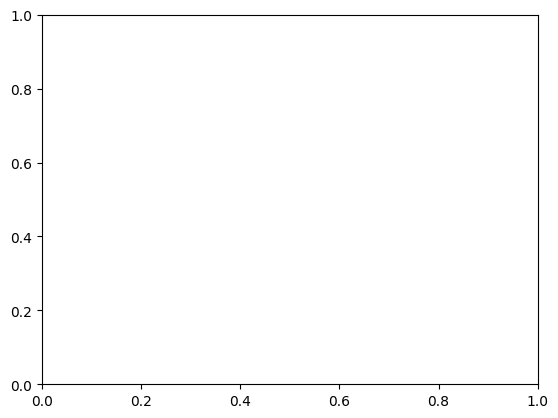

In [22]:
safe_config = (x >= -2) & (x <= 2) & (y >= -2) & (y <= 2) & (x**2 + y**2 >= sp.Rational(1, 4))
show_call("safe configuration satisfiable", lambda: is_satisfiable(safe_config, [x, y]))
try:
    plot_solution(safe_config, bounds=[(-2.2, 2.2), (-2.2, 2.2)], raster_resolution=250, title="Safe box with circular obstacle")
except Exception as exc:
    print(f"plot unavailable: {type(exc).__name__}: {exc}")


### Verification and invariants

Polynomial inequalities can encode safety or invariance claims. For example, a Lyapunov-like candidate $V=x^2+y^2$ is nonnegative everywhere, which can be proven by a real-algebraic decision procedure.


In [23]:
show_call("prove x^2 + y^2 is nonnegative", lambda: prove_nonnegative(x**2 + y**2, [x, y]))



--- prove x^2 + y^2 is nonnegative ---
True


True

### Computational geometry

Region operations and exact inequalities can express intersections, containment, convex-like constraints, and geometric measurements.


In [24]:
show_call("area of lens", lambda: semialgebraic_measure(lens, [x, y]))
show_call("is lens contained in disk1?", lambda: implies(lens, disk1, [x, y]))



--- area of lens ---
-2*asin(1/4) - sqrt(15)/8 + pi

--- is lens contained in disk1? ---
True


True

## 21. Exact vs numeric workflows

Exact symbolic methods and numeric visualization answer different questions.

- Exact QE can prove a statement for all real values.
- Sampling can find witnesses and counterexamples but is not a proof.
- Plotting can reveal structure but may miss thin components or boundary phenomena.


In [25]:
exact_condition = show_call(
    "exact bound condition",
    lambda: reduce_text("forall x. (-1 <= x and x <= 1) implies x^2 <= b", variable_order=[b, x]),
)

sampled = show_call("sample points satisfying x^2 <= 1", lambda: sample_points(x**2 <= 1, [x], count=5))



--- exact bound condition ---
b >= 1

--- sample points satisfying x^2 <= 1 ---
({x: 0}, {x: 1}, {x: -1}, {x: 1/2}, {x: -1/2})


## 22. Performance tips and limitations

CAD is general, but its worst-case complexity is doubly exponential in the number of variables. Practical performance depends strongly on structure.

Useful strategies:

1. keep variable counts low;
2. choose variable order carefully;
3. simplify formulas before CAD;
4. use RUR for zero-dimensional equality systems;
5. exploit equational constraints when possible;
6. use one-dimensional, quadratic, radial, or vertical-bound special cases;
7. use plotting only after exact formulas have been reduced or decomposed.

Variable order often matters because CAD eliminates variables in an ordered way. A good order can keep projection polynomials simple; a poor order can create many unnecessary resultants.


In [26]:
order_sensitive_text = "exists y. y - x^2 = 0 and y <= a"
show_call("order [a, x, y]", lambda: reduce_text(order_sensitive_text, variable_order=[a, x, y]))
show_call("order [x, a, y]", lambda: reduce_text(order_sensitive_text, variable_order=[x, a, y]))



--- order [a, x, y] ---
False

--- order [x, a, y] ---
False


False

## 23. Developer notes and extension points

The public API is intentionally layered:

- top-level user functions live under `semialg.__init__`;
- CAD and decomposition code live under decomposition/CAD modules;
- zero-dimensional solving and RUR are solver backends;
- region operations, moments, integration, and optimization are higher-level workflows;
- plotting is a convenience layer over exact or sampled geometry.

A good backend should return structured metadata rather than only a formula. Useful metadata includes:

- variables and parameter variables;
- backend/method name;
- exact formula result;
- sample points or witness points;
- decomposition cells when available;
- algebraic-number or RUR data when solutions are finite;
- warnings or explicit unsupported-feature notes.



## 24. Decision-layer contracts

The public decision layer has a stable set of contracts that are worth testing and using directly in notebooks:

- the simple calls still return booleans by default;
- `return_result=True` returns structured result objects;
- witnesses and counterexamples are validated before being returned;
- `solve_semialgebraic(..., count=0)` analyzes a set without collecting sample points;
- sampling strategies are explicit (`representative`, `rational`, `grid`, `random`, `cad_cells`);
- exact sign evaluation is the default for rational, algebraic, and RUR-backed points.


In [27]:
# Boolean API versus structured result API
x = sp.symbols("x", real=True)

print(is_satisfiable((x >= 0) & (x <= 1), [x]))
implication = implies(x >= 0, x > 0, [x], return_result=True)
print(type(implication).__name__, implication.valid, implication.counterexample)


True
ImplicationResult False {x: 0}


In [28]:
# count=0 means solve/analyze without collecting samples
y = sp.symbols("y", real=True)
triangle = (x >= 0) & (x <= 1) & (y >= x) & (y <= 1)
triangle_solution = solve_semialgebraic(triangle, [x, y], count=0)
print(triangle_solution.satisfiable, triangle_solution.samples, triangle_solution.method)


True () vertical_bounds_2d


In [29]:
# Sampling strategy examples
print(sample_point(sp.Eq(x**2, 2), [x], strategy="representative"))
print(sample_points((x >= 0) & (x <= 1), [x], count=3, strategy="rational"))
print(sample_points((x >= 0) & (x <= 1), [x], count=3, strategy="random", bounds=[(0, 1)], seed=4, exact=False))


{x: -sqrt(2)}
({x: 0}, {x: 1}, {x: 1/2})
({x: 0.236048089737434518831094010238}, {x: 0.103166034230715797370692143886}, {x: 0.396058242610681010553719261225})


In [31]:
# Exact sign evaluation examples
from semialg.sampling import sign_at, sign_vector

print(sign_at(x**2 - 2, {x: sp.sqrt(2)}))
print(sign_vector([x, x - 1, x**2 - 1], {x: 0}, as_dict=True))

0
{x: 0, x - 1: -1, x**2 - 1: -1}



The tests for these contracts live in `the decision-layer regression files. Those tests are intentionally public-API-level: they check behavior users rely on rather than private implementation details.


## 25. Summary

This demo notebook covered:

- semialgebraic formulas and real algebraic geometry basics;
- satisfiability, implication, equivalence, and sampling;
- CAD as sign-invariant cell decomposition;
- quantifier elimination as projection and parameter synthesis;
- RUR for exact zero-dimensional solving;
- region algebra, plotting, optimization, integration, moments, topology, and applications;
- exact vs numeric workflows and performance limitations.

The central lesson is that `semialg` is not merely a plotting or sampling tool. Its purpose is exact symbolic reasoning about real polynomial constraints, with numerical visualization used only as an aid.
